Phase 1: Data Augmentation & **Training**

CELL 1

In [ ]:
!pip install albumentations -q

CELL 2

In [13]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR = '/content/drive/MyDrive/mars_project'
train_dir = os.path.join(BASE_DIR, 'train')
val_dir   = os.path.join(BASE_DIR, 'val')
test_dir  = os.path.join(BASE_DIR, 'test')

# Quick sanity check
for d in [train_dir, val_dir, test_dir]:
    if not os.path.exists(d):
        raise FileNotFoundError(f"Folder not found: {d}\nCheck your Drive folder structure.")

print("Train images:", len(os.listdir(train_dir)))
print("Val images:  ", len(os.listdir(val_dir)))
print("Test images: ", len(os.listdir(test_dir)))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train images: 647
Val images:   80
Test images:  81


CELL 3 (IMPORTS)

In [14]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image
import albumentations as A
import matplotlib.pyplot as plt
import pickle

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


CELL 4 - AUGMENTATION PIPELINE

In [15]:
# Milder augmentation: just flips, rotations, and slight lighting changes
train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
])

def load_images_and_labels(data_dir, augment=False, aug_pipeline=None):
    images, labels = [], []
    valid_exts = ('.jpg', '.jpeg', '.png')
    for file_name in sorted([f for f in os.listdir(data_dir) if f.lower().endswith(valid_exts)]):
        if '_' not in file_name: continue
        try:
            img = Image.open(os.path.join(data_dir, file_name)).convert('RGB').resize((224, 224))
            img_np = np.array(img)
            label = file_name.split('_')[0]
            images.append(img_np / 255.0)
            labels.append(label)
            if augment and aug_pipeline is not None:
                for _ in range(3):
                    aug_result = aug_pipeline(image=img_np)
                    images.append(aug_result['image'] / 255.0)
                    labels.append(label)
        except Exception: continue
    return np.array(images, dtype=np.float32), np.array(labels)

train_images, train_labels = load_images_and_labels(train_dir, augment=True, aug_pipeline=train_aug)
val_images,  val_labels  = load_images_and_labels(val_dir)
test_images, test_labels = load_images_and_labels(test_dir)

CELL 5 - LABEL ENCODING + CLASS WEIGHT

In [16]:
label_encoder = LabelEncoder()
train_enc = label_encoder.fit_transform(train_labels)
val_enc   = label_encoder.transform(val_labels)
test_enc  = label_encoder.transform(test_labels)

NUM_CLASSES = len(label_encoder.classes_)
print("Classes found:", list(label_encoder.classes_))
print("Number of classes:", NUM_CLASSES)

# Save label encoder — required by Phase 2 and Phase 3
with open(os.path.join(BASE_DIR, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(label_encoder, f)
print("label_encoder.pkl saved to Drive.")

train_oh = to_categorical(train_enc, NUM_CLASSES)
val_oh   = to_categorical(val_enc,   NUM_CLASSES)
test_oh  = to_categorical(test_enc,  NUM_CLASSES)

# Compute balanced class weights (uses original un-augmented label counts)
# We use train_enc which has augmented labels too — that's fine,
# the ratio between classes stays the same.
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_enc),
    y=train_enc
)
class_weights = dict(enumerate(class_weights_array))
print("\nClass weights (higher number = rarer class gets more penalty):")
for idx, w in class_weights.items():
    print(f"  {label_encoder.classes_[idx]}: {w:.3f}")

Classes found: [np.str_('cracked'), np.str_('gravel'), np.str_('sand'), np.str_('sedimentary')]
Number of classes: 4
label_encoder.pkl saved to Drive.

Class weights (higher number = rarer class gets more penalty):
  cracked: 1.444
  gravel: 1.093
  sand: 0.930
  sedimentary: 0.759


CELL 6 - tf.data pipeline

In [17]:
BATCH_SIZE = 16  # 16 instead of your original 32 — EfficientNetB3 is bigger

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_images, train_oh))
    .shuffle(buffer_size=len(train_images), seed=42)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_images, val_oh))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_images, test_oh))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Datasets ready.")

Datasets ready.


CELL 7 - Build EfficientNetB3 transfer learning model

In [18]:
def build_model(num_classes):
    # EfficientNetB3 without ImageNet's 1000-class top head
    base_model = EfficientNetB3(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False  # Start fully frozen

    inputs = tf.keras.Input(shape=(224, 224, 3))

    # training=False → keep BatchNorm layers in inference mode (important!)
    x = base_model(inputs, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu', name='dense_256')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu', name='dense_128')(x)  # embedding layer
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = Model(inputs, outputs)
    return model, base_model


model, base_model = build_model(NUM_CLASSES)

# Quick param count
trainable_params   = sum(tf.size(w).numpy() for w in model.trainable_weights)
nontrain_params    = sum(tf.size(w).numpy() for w in model.non_trainable_weights)
print(f"Trainable params:     {trainable_params:,}")
print(f"Non-trainable params: {nontrain_params:,}")
print("(Most params are frozen — only the head trains in Stage 1)")

Trainable params:     429,956
Non-trainable params: 10,786,607
(Most params are frozen — only the head trains in Stage 1)


CELL 8 - Stage 1: Train custom head only

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_stage1 = [
    EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    ),
]

print("\n═══ STAGE 1: Training new head (EfficientNetB3 fully frozen) ═══")
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks_stage1,
    verbose=1
)

stage1_val_acc = max(history1.history['val_accuracy']) * 100
print(f"\nStage 1 best val accuracy: {stage1_val_acc:.2f}%")


═══ STAGE 1: Training new head (EfficientNetB3 fully frozen) ═══
Epoch 1/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 97s 298ms/step - accuracy: 0.3474 - loss: 1.6810 - val_accuracy: 0.3125 - val_loss: 1.3654 - learning_rate: 0.0010
Epoch 2/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.3679 - loss: 1.3912 - val_accuracy: 0.3375 - val_loss: 1.3303 - learning_rate: 0.0010
Epoch 3/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.3980 - loss: 1.3090 - val_accuracy: 0.3875 - val_loss: 1.2612 - learning_rate: 0.0010
Epoch 4/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.4127 - loss: 1.2974 - val_accuracy: 0.3875 - val_loss: 1.2533 - learning_rate: 0.0010
Epoch 5/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.4359 - loss: 1.2635 - val_accuracy: 0.3875 - val_loss: 1.2289 - learning_rate: 0.0010
Epoch 6/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.4316 - loss: 1.2482 - val_accuracy: 0.3875 - val_loss: 1.2172 - learning_rate: 0.0010
Epoch 7/15
16

CELL 9 — Stage 2: Fine-tune top 30 layers of EfficientNetB3

In [20]:
base_model.trainable = True

# Unfreeze the top 100 layers instead of just 30
for layer in base_model.layers[:-100]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy', metrics=['accuracy'])

callbacks_stage2 = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint(os.path.join(BASE_DIR, 'best_model_checkpoint.keras'), save_best_only=True)
]

history2 = model.fit(train_ds, validation_data=val_ds, epochs=25,
                     class_weight=class_weights, callbacks=callbacks_stage2, verbose=1)

Epoch 1/25
162/162 ━━━━━━━━━━━━━━━━━━━━ 115s 336ms/step - accuracy: 0.4030 - loss: 1.3275 - val_accuracy: 0.3125 - val_loss: 1.2662 - learning_rate: 1.0000e-04
Epoch 2/25
162/162 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step - accuracy: 0.4629 - loss: 1.2411 - val_accuracy: 0.2875 - val_loss: 1.2224 - learning_rate: 1.0000e-04
Epoch 3/25
162/162 ━━━━━━━━━━━━━━━━━━━━ 19s 79ms/step - accuracy: 0.4386 - loss: 1.2730 - val_accuracy: 0.4750 - val_loss: 1.1871 - learning_rate: 1.0000e-04
Epoch 4/25
162/162 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.4741 - loss: 1.2195 - val_accuracy: 0.5250 - val_loss: 1.0570 - learning_rate: 1.0000e-04
Epoch 5/25
162/162 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step - accuracy: 0.4683 - loss: 1.2124 - val_accuracy: 0.5500 - val_loss: 1.0730 - learning_rate: 1.0000e-04
Epoch 6/25
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.4919 - loss: 1.2092 - val_accuracy: 0.5375 - val_loss: 1.1142 - learning_rate: 1.0000e-04
Epoch 7/25
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/s

Cell 9.5 (Stage 3: Deep Fine-Tuning)

In [21]:
# Unfreeze way more of the model (top 250 layers)
base_model.trainable = True
for layer in base_model.layers[:-250]:
    layer.trainable = False

# Recompile with a gentle learning rate (2e-5) to carefully polish the weights
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
              loss='categorical_crossentropy', metrics=['accuracy'])

# Give it 40 epochs, with plenty of patience
callbacks_stage3 = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint(os.path.join(BASE_DIR, 'best_model_checkpoint.keras'), save_best_only=True)
]

print("\n═══ STAGE 3: Deep Fine-Tuning ═══")
history3 = model.fit(train_ds, validation_data=val_ds, epochs=40,
                     class_weight=class_weights, callbacks=callbacks_stage3, verbose=1)


═══ STAGE 3: Deep Fine-Tuning ═══
Epoch 1/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 129s 337ms/step - accuracy: 0.5444 - loss: 1.0856 - val_accuracy: 0.4875 - val_loss: 0.9643 - learning_rate: 2.0000e-05
Epoch 2/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.5174 - loss: 1.0749 - val_accuracy: 0.4375 - val_loss: 1.0399 - learning_rate: 2.0000e-05
Epoch 3/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - accuracy: 0.5440 - loss: 1.0739 - val_accuracy: 0.5250 - val_loss: 0.9319 - learning_rate: 2.0000e-05
Epoch 4/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.5456 - loss: 1.0717 - val_accuracy: 0.4250 - val_loss: 1.1016 - learning_rate: 2.0000e-05
Epoch 5/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - accuracy: 0.5425 - loss: 1.0730 - val_accuracy: 0.5250 - val_loss: 0.9691 - learning_rate: 2.0000e-05
Epoch 6/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.5363 - loss: 1.0622 - val_accuracy: 0.4625 - val_loss: 1.0230 - learning_rate: 2.0000e-05
Epoch 7/40
162/

CELL 10 — Evaluate on held-out test set

In [22]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\n✅ Final Test Accuracy: {test_acc * 100:.2f}%")
print(f"   Test Loss:           {test_loss:.4f}")
print("\nNote: write this number down — use it as the baseline in Phase 3 plots.")

6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.6420 - loss: 0.7461

✅ Final Test Accuracy: 64.20%
   Test Loss:           0.7461

Note: write this number down — use it as the baseline in Phase 3 plots.


CELL 11 Plot Graphs

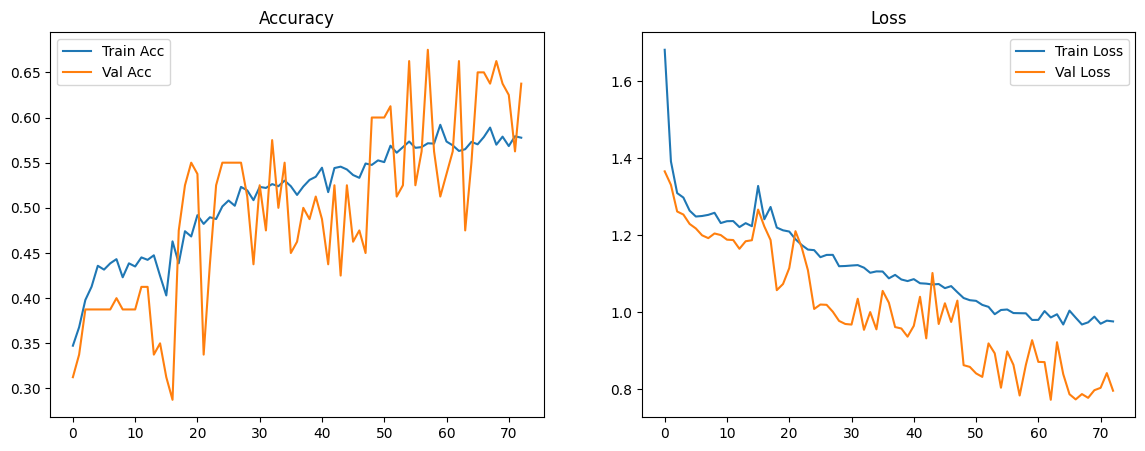

In [23]:
acc      = history1.history['accuracy']     + history2.history['accuracy']     + history3.history['accuracy']
val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy'] + history3.history['val_accuracy']
loss     = history1.history['loss']         + history2.history['loss']         + history3.history['loss']
val_loss = history1.history['val_loss']     + history2.history['val_loss']     + history3.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(acc, label='Train Acc')
axes[0].plot(val_acc, label='Val Acc')
axes[0].legend()
axes[0].set_title('Accuracy')

axes[1].plot(loss, label='Train Loss')
axes[1].plot(val_loss, label='Val Loss')
axes[1].legend()
axes[1].set_title('Loss')

plt.savefig(os.path.join(BASE_DIR, 'phase1_training_curves.png'))
plt.show()

CELL - Final Model

In [24]:
save_path = os.path.join(BASE_DIR, 'mars_phase1_efficientnet.keras')
model.save(save_path)
print(f"\nModel saved: {save_path}")
print("This file is needed by Phase 2, Phase 3, and Phase 4.")
print("\n✅ PHASE 1 COMPLETE — open Phase 2 notebook next")


Model saved: /content/drive/MyDrive/mars_project/mars_phase1_efficientnet.keras
This file is needed by Phase 2, Phase 3, and Phase 4.

✅ PHASE 1 COMPLETE — open Phase 2 notebook next
